In [ ]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Load dataset
df = pd.read_csv("cb_multi_labeled_balanced.csv")
df.tail()

,text,label
99985,Thank fuck they didn’t dance remix Peru #LoveI...,not_cyberbullying
99986,Sierra Canyon vs. Alemany - California High Sc...,not_cyberbullying
99987,@queenbellaxoxo @PontiacMadeDDG @HalleBailey B...,gender/sexual
99988,What you like yo nigga to call you,ethnicity/race
99989,@kirkfranklin Happy CAKE DAY 🌬🎂🎁🎈🎉,not_cyberbullying


In [ ]:
#Explore the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99990 entries, 0 to 99989
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    99990 non-null  object
 1   label   99990 non-null  object
dtypes: object(2)
memory usage: 1.5+ MB


In [ ]:
df.isnull().sum()

,0
text,0
label,0


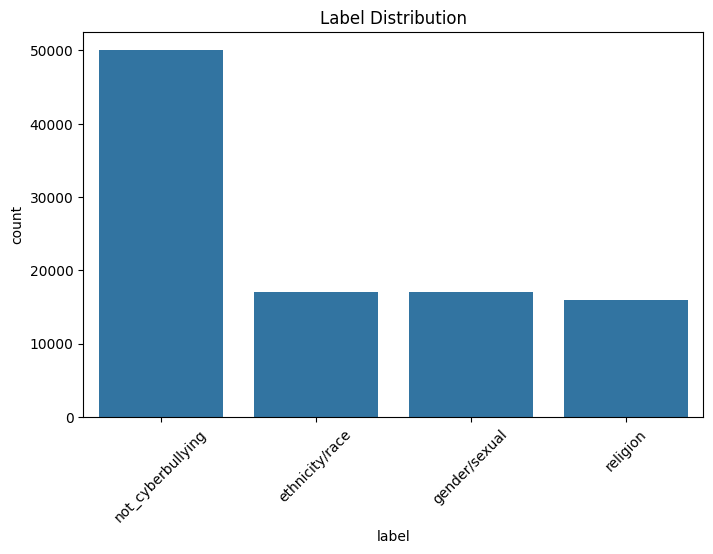

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index)
plt.title("Label Distribution")
plt.xticks(rotation=45)
plt.show()

In [ ]:
df["text_length"] = df["text"].apply(lambda x: len(str(x).split()))
df["text_length"].describe()

,text_length
count,99990.000000
mean,21.330953
std,13.461627
min,1.000000
25%,11.000000
50%,17.000000
75%,29.000000
max,96.000000


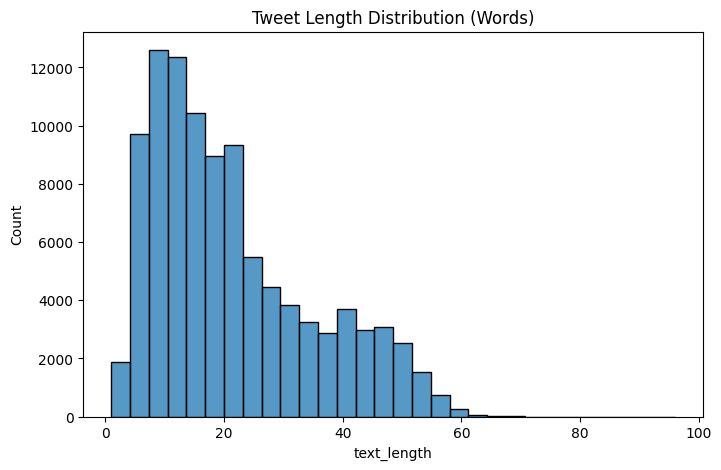

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["text_length"], bins=30)
plt.title("Tweet Length Distribution (Words)")
plt.show()

In [ ]:
df.sample(5)

,text,label,text_length
21621,@culchiemaxxed @detectfights Nothing worth res...,ethnicity/race,16
85597,@StanRothstein23 @ThaJuice919 Bitch ain’t play...,gender/sexual,16
20630,@catmedicactual @AmyBuchananan @FromtheAtotheE...,ethnicity/race,25
97752,We made it through the 365 days and here we ar...,not_cyberbullying,23
43373,Getting hate for all the right reasons! My fir...,religion,51


In [ ]:
#Data Cleaning
import re
import string

def clean_text(text):
    text = text.lower()                              # lowercase
    text = re.sub(r'http\S+', '', text)              # remove URLs
    text = re.sub(r'@\w+', '', text)                 # remove @mentions
    text = re.sub(r'#\w+', '', text)                 # remove hashtags
    text = text.translate(str.maketrans('', '', string.punctuation))  # punctuation
    text = re.sub(r'\d+', '', text)                  # remove numbers
    text = re.sub(r'[\U00010000-\U0010ffff]', '', text) #remove emojis
    text = text.strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)
df[["text", "clean_text"]].tail()

,text,clean_text
99985,Thank fuck they didn’t dance remix Peru #LoveI...,thank fuck they didn’t dance remix peru
99986,Sierra Canyon vs. Alemany - California High Sc...,sierra canyon vs alemany california high scho...
99987,@queenbellaxoxo @PontiacMadeDDG @HalleBailey B...,bitch i wasn’t flirting i was snitching
99988,What you like yo nigga to call you,what you like yo nigga to call you
99989,@kirkfranklin Happy CAKE DAY 🌬🎂🎁🎈🎉,happy cake day


In [ ]:
#Train–test split
from sklearn.model_selection import train_test_split

df["clean_text"] = df["text"].apply(clean_text)

X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
#TF-IDF vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

In [ ]:
#Train model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=300)
model.fit(X_train_vec, y_train)


LogisticRegression(max_iter=300)

In [ ]:
#Model Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9878487848784878

Classification Report:
                    precision    recall  f1-score   support

   ethnicity/race       1.00      0.99      0.99      3400
    gender/sexual       0.99      0.99      0.99      3400
not_cyberbullying       0.98      1.00      0.99     10000
         religion       1.00      0.96      0.98      3198

         accuracy                           0.99     19998
        macro avg       0.99      0.98      0.99     19998
     weighted avg       0.99      0.99      0.99     19998



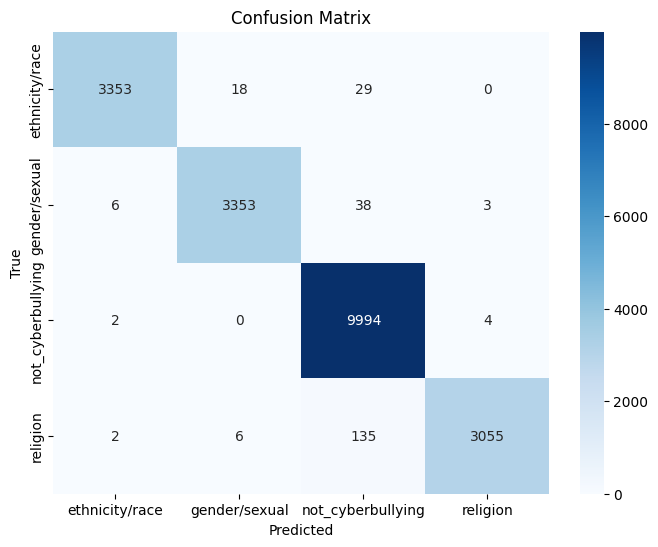

In [ ]:
#Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
#Samples
sample_texts = [
    "Stupid bitch, shut up",
    "You are beautiful today",
]

sample_clean = [clean_text(t) for t in sample_texts]
sample_vec = vectorizer.transform(sample_clean)
model.predict(sample_vec)

array(['gender/sexual', 'not_cyberbullying'], dtype=object)